In [25]:
import numpy as np
import matplotlib.pyplot as plt

from tqdm import tqdm

import matplotlib.cm as cm
import colormaps as cmaps
import matplotlib.colors as colors
from labellines import labelLines
from matplotlib.cm import brg, ScalarMappable
from matplotlib.colors import (
    LogNorm,
    TwoSlopeNorm,
    LinearSegmentedColormap,
    Normalize,
    ListedColormap,
)
from matplotlib.lines import Line2D

import jax
import jax.numpy as jnp
from mpl_toolkits.axes_grid1.inset_locator import inset_axes

import yaml
from pathlib import Path

import EI.ei_unified as eu
import EI.ei_jax as ej
import EI.ei_phonon as pb

from utils.logger import logger, tqdm_bar
from utils.plotting_utils import Plotter, plot_cmap, format_ax, add_legend, plot_cmap, plot_phase_diag, color_map


import importlib
pb = importlib.reload(pb)
ej = importlib.reload(ej)
jax.clear_caches()

In [26]:
from utils.cosmetics import apply_plt_style, SET1_LIST
apply_plt_style()

OUT = "/home/kzeleznikar/IJS-F1/Koda/EI_baths/"
from matplotlib_inline.backend_inline import set_matplotlib_formats
set_matplotlib_formats("png", dpi=300)

In [ ]:
nkq = 200
nv = 201

va = np.linspace(0.0, 25.0, nv)

bdq = eu.tb_2d(
    nk=nkq,
    gap=2.0,
    ta=1.0,
    tb=-1.0,
)

x0 = 0.5 * (
    np.asarray(bdq.ea)
    - np.asarray(bdq.eb)
)


pp = (
    (np.sqrt(5.0) - 1.0)
    / (np.sqrt(5.0) + 1.0)
)

ww = np.asarray(bdq.w, dtype=float)
ww = ww / np.sum(ww)

if np.any(~np.isfinite(ww)) or np.any(ww < 0.0):
    raise ValueError("Invalid momentum weights")

print("Weight sum:", np.sum(ww))

def fm(m, d, v):
    x = x0 - 0.5 * v * m
    e = np.sqrt(x**2 + d**2)

    return m + pp * np.sum(
        ww * x / e
    )
def get_m(d, v):
    ml = -1.0
    mh = 1.0

    fl = fm(ml, d, v)
    fh = fm(mh, d, v)

    if not np.isfinite(fl) or not np.isfinite(fh):
        raise ValueError(
            f"Nonfinite m residual at d={d}, V={v}"
        )

    if fl > 0.0 or fh < 0.0:
        raise ValueError(
            f"Could not bracket m at d={d:.3e}, V={v:.3e}: "
            f"f(-1)={fl:.3e}, f(1)={fh:.3e}"
        )

    return brentq(
        lambda m: fm(m, d, v),
        ml,
        mh,
        xtol=1.0e-12,
        rtol=1.0e-12,
    )


def fg(d, v):
    m = get_m(d, v)

    x = x0 - 0.5 * v * m
    e = np.sqrt(x**2 + d**2)

    return (
        pp * v
        * np.sum(ww / (2.0 * e))
        - 1.0
    )

dl = 1.0e-8
da = np.zeros(nv)
ma = np.zeros(nv)
la = np.zeros(nv)

bar = tqdm(range(nv), desc="V sweep")

for i in bar:
    v = va[i]

    ma[i] = get_m(dl, v)

    x = x0 - 0.5 * v * ma[i]
    e = np.sqrt(x**2 + dl**2)

    la[i] = (
        pp * v
        * np.sum(ww / (2.0 * e))
    )

    if v > 0.0 and la[i] > 1.0:
        dh = max(v, 10.0 * dl)

        da[i] = brentq(
            lambda d: fg(d, v),
            dl,
            dh,
            xtol=1.0e-11,
            rtol=1.0e-11,
        )

        ma[i] = get_m(da[i], v)

    bar.set_postfix(
        v=f"{v:.2f}",
        d=f"{da[i]:.3e}",
        m=f"{ma[i]:.3f}",
        lam=f"{la[i]:.3f}",
    )

ix = da > 10.0 * dl

if np.any(ix):
    im = np.argmax(da)

    print(
        "Resolved ordered interval:",
        f"{va[ix][0]:.6f} < V < {va[ix][-1]:.6f}",
    )

    print(
        "Maximum:",
        f"Delta = {da[im]:.8f}",
        f"at V = {va[im]:.8f}",
    )
else:
    print("No resolved nonzero solution")

Weight sum: 0.9999999999999996


V sweep:   0%|          | 0/201 [00:00<?, ?it/s]

Resolved ordered interval: 0.500000 < V < 21.750000
Maximum: Delta = 1.37976526 at V = 16.75000000


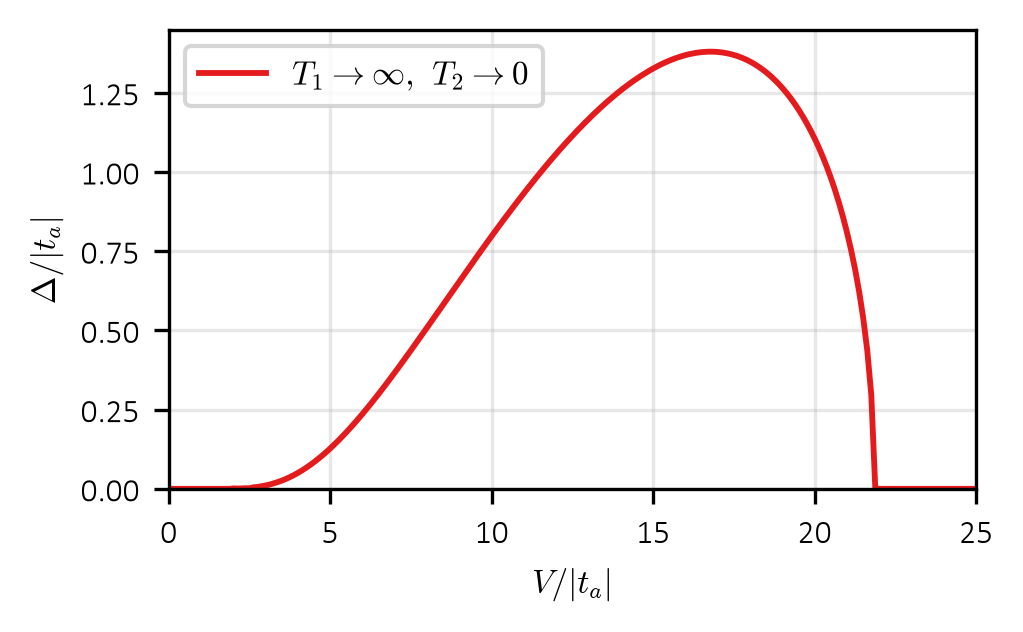

In [28]:
h = 0.62
fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

ax.plot(
    va,
    da,
    color=SET1_LIST[0],
    linewidth=1.4,
    label=r"$T_1\to\infty,\ T_2\to0$",
)

ax.set_xlim(va[0], va[-1])
ax.set_ylim(bottom=0.0)

ax.set_xlabel(r"$V/|t_a|$")
ax.set_ylabel(r"$\Delta/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(loc="best")

plt.tight_layout()
plt.show()

In [29]:
from scipy.optimize import brentq
from tqdm.auto import tqdm

# Make sure the integration weights are normalized
ww = np.asarray(ww, dtype=float)
ww = ww / np.sum(ww)

deq = np.zeros_like(va)
meq = np.zeros_like(va)
leq = np.zeros_like(va)

dmin = 1.0e-8


def fm_eq(m, d, v):
    xi = x0 - 0.5 * v * m
    ek = np.sqrt(xi**2 + d**2)

    return m + np.sum(
        ww * xi / ek
    )


def get_m_eq(d, v):
    ml = -1.0
    mr = 1.0

    fl = fm_eq(ml, d, v)
    fr = fm_eq(mr, d, v)

    # Handle roots numerically located at the physical boundaries
    mtol = 1.0e-12

    if abs(fl) < mtol:
        return ml

    if abs(fr) < mtol:
        return mr

    if fl * fr > 0.0:
        raise ValueError(
            "Could not bracket m: "
            f"V={v:.8f}, d={d:.3e}, "
            f"F(-1)={fl:.3e}, F(1)={fr:.3e}, "
            f"sum(w)={np.sum(ww):.16f}, "
            f"min(w)={np.min(ww):.3e}"
        )

    return brentq(
        lambda m: fm_eq(m, d, v),
        ml,
        mr,
        xtol=1.0e-12,
        rtol=1.0e-12,
        maxiter=500,
    )


def fg_eq(d, v):
    m = get_m_eq(d, v)

    xi = x0 - 0.5 * v * m
    ek = np.sqrt(xi**2 + d**2)

    return (
        v * np.sum(ww / (2.0 * ek))
        - 1.0
    )


bar = tqdm(range(va.size), desc="Equilibrium T=0")

for i in bar:
    v0 = va[i]

    if v0 == 0.0:
        deq[i] = 0.0
        meq[i] = get_m_eq(dmin, v0)
        leq[i] = 0.0
        continue

    # Normal-state Hartree solution
    meq[i] = get_m_eq(dmin, v0)

    xi = x0 - 0.5 * v0 * meq[i]
    ek = np.sqrt(xi**2 + dmin**2)

    # Linearized pairing eigenvalue
    leq[i] = v0 * np.sum(
        ww / (2.0 * ek)
    )

    if leq[i] > 1.0:
        # Delta <= V/2, but V is a conservative upper bracket
        dhi = max(v0, 10.0 * dmin)

        fhi = fg_eq(dhi, v0)

        # Expand only if roundoff or an unusual dispersion
        while fhi > 0.0:
            dhi *= 2.0
            fhi = fg_eq(dhi, v0)

        deq[i] = brentq(
            lambda d: fg_eq(d, v0),
            dmin,
            dhi,
            xtol=1.0e-11,
            rtol=1.0e-11,
            maxiter=500,
        )

        meq[i] = get_m_eq(deq[i], v0)

    bar.set_postfix(
        v=f"{v0:.2f}",
        d=f"{deq[i]:.4f}",
        m=f"{meq[i]:.4f}",
    )

Equilibrium T=0:   0%|          | 0/201 [00:00<?, ?it/s]

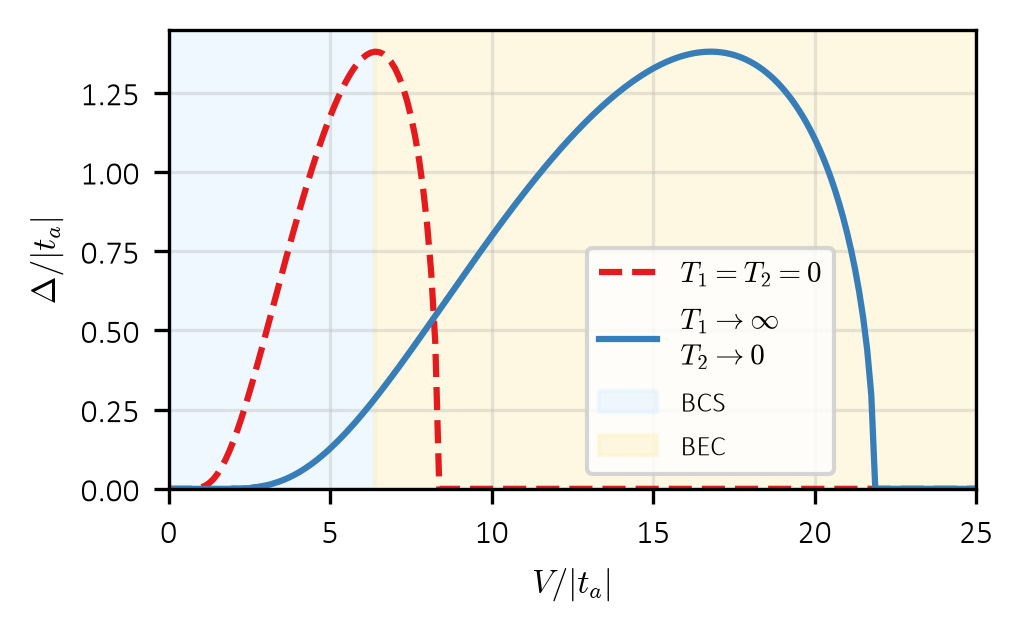

In [38]:
h = 0.62

fig, ax = plt.subplots(
    figsize=(3.47412, h * 3.47412)
)

ax.plot(
    va,
    deq,
    color=SET1_LIST[0],
    linestyle="--",
    linewidth=1.5,
    label=r"$T_1=T_2=0$",
)
max_idx = np.argmax(deq)
v_max = va[max_idx]

ax.plot(
    va,
    da,
    color=SET1_LIST[1],
    linewidth=1.5,
    label=(
        r"$T_1\to\infty$" "\n" r"$ T_2\to0$"
    ),
)


ax.axvspan(va[0], v_max, color="#e0f2fe", alpha=0.5, zorder=0, label="BCS")
ax.axvspan(v_max, va[-1], color="#fef3c7", alpha=0.5, zorder=0, label="BEC")

ax.set_xlim(va[0], va[-1])
ax.set_ylim(bottom=0.0)

ax.set_xlabel(r"$V/|t_a|$")
ax.set_ylabel(r"$\Delta/|t_a|$")

ax.grid(alpha=0.3)
ax.legend(loc=3, bbox_to_anchor=(0.5, 0), fontsize=7)

plt.tight_layout()
plt.savefig("Gap_V_Tinf_prod_baths.pdf")
plt.show()